In [5]:
from dotenv import load_dotenv
import pm4py
import warnings
import pandas as pd
import os
load_dotenv()

True

[   20 20000] -> (np.int64(0), np.int64(4))
[   22 22000] -> (np.int64(0), np.int64(2))
[   25 25000] -> (np.int64(2), np.int64(4))
[   50 80000] -> (np.int64(4), np.int64(3))
[   52 85000] -> (np.int64(4), np.int64(1))
[   55 90000] -> (np.int64(2), np.int64(0))


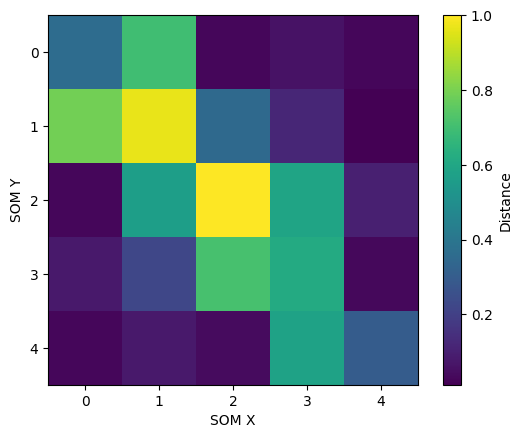

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler


# -----------------------
# 1. Data
# -----------------------

X = np.array([
    [20, 20000],
    [22, 22000],
    [25, 25000],
    [50, 80000],
    [52, 85000],
    [55, 90000]
])


# -----------------------
# 2. Scale data
# -----------------------

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# -----------------------
# 3. Create SOM
# -----------------------

som = MiniSom(
    x=5,
    y=5,
    input_len=X.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    topology='hexagonal',
    activation_distance='euclidean',
    random_seed=42
)


# -----------------------
# 4. Initialize
# -----------------------

som.random_weights_init(X_scaled)


# -----------------------
# 5. Train
# -----------------------

som.train_random(
    X_scaled,
    num_iteration=1000
)


# -----------------------
# 6. Find BMUs
# -----------------------

for original, scaled in zip(X, X_scaled):
    winner = som.winner(scaled)

    print(original, "->", winner)


# -----------------------
# 7. Visualize
# -----------------------

plt.imshow(som.distance_map().T)
plt.colorbar(label="Distance")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.show()